# Portfolio Project: Automobile Price Analysis and Regression Modeling 

---

# 04 — Regression Model Development
## Automobile Pricing Analytics

### Analytical purpose
This notebook translates the relationships identified in **Notebook 03 — Exploratory Data Analysis** into explicit regression models of automobile price.

The emphasis is on **classical regression specification and interpretation**.

### Objectives
1. Develop and interpret **Simple Linear Regression (SLR)** models.
2. Develop a **Multiple Linear Regression (MLR)** model using predictors motivated by the EDA.
3. Examine whether a **polynomial specification** captures nonlinearity better than a straight-line model.
4. Compare model fit using in-sample diagnostics such as **R², MSE, RMSE, and MAE**.
5. Inspect fitted values and residuals to identify limitations that should be tested formally in Notebook 05.

### Important evaluation boundary
All fit statistics in this notebook are **in-sample**: the models are evaluated on the same observations used for estimation. They describe how well each specification represents the observed data, but they do **not** establish out-of-sample predictive performance.

Notebook 05 will perform train/test evaluation, cross-validation, overfitting analysis, and final model selection.


## 1. Setup and load the cleaned dataset

The analysis-ready dataset from Notebook 02 is loaded directly. No additional cleaning or imputation is performed here.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

candidate_paths = [
    Path("../data/auto_cleaned.csv"),
    Path("data/auto_cleaned.csv"),
    Path("auto_cleaned.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "auto_cleaned.csv was not found. Run Notebook 02 first or place the file "
        "in ../data/, data/, or the current directory."
    )

df = pd.read_csv(data_path)

print(f"Dataset location: {data_path.resolve()}")
print(f"Shape: {df.shape}")

Dataset location: /mnt/data/auto_cleaned.csv
Shape: (201, 29)


In [2]:
required_columns = {
    "price", "highway-mpg", "engine-size",
    "horsepower", "curb-weight"
}

missing = required_columns.difference(df.columns)
assert not missing, f"Missing required columns: {sorted(missing)}"
assert df[list(required_columns)].notna().all().all()

df[list(required_columns)].head()

,engine-size,curb-weight,horsepower,price,highway-mpg
0,130,2548,111.000,"13,495.000",27
1,130,2548,111.000,"16,500.000",27
2,152,2823,154.000,"16,500.000",26
3,109,2337,102.000,"13,950.000",30
4,136,2824,115.000,"17,450.000",22


## 2. Evaluation functions used in this notebook

Four metrics are reported consistently:

- **R²**: proportion of observed price variation explained by the fitted model.
- **MSE**: average squared prediction error.
- **RMSE**: square root of MSE, expressed in dollars.
- **MAE**: average absolute prediction error, also expressed in dollars.

Because these are calculated on the estimation sample in Notebook 04, they are useful for comparing model fit but should not be interpreted as unbiased measures of future predictive accuracy.


In [3]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "R2": r2_score(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


model_results = []

# Part I — Simple Linear Regression

Simple Linear Regression estimates the relationship between price and one predictor at a time.

The EDA showed that:
- `highway-mpg` has a strong **negative** association with price;
- `engine-size` has one of the strongest **positive** associations with price.

Both are therefore examined as transparent one-predictor specifications.


## 3. SLR Model 1 — Highway MPG

The first specification follows the original project and models automobile price as a linear function of highway fuel economy.

The fitted equation has the form:

**Price = intercept + slope × highway-mpg**


In [4]:
X_highway = df[["highway-mpg"]]
y = df["price"]

slr_highway = LinearRegression()
slr_highway.fit(X_highway, y)

pred_highway = slr_highway.predict(X_highway)

print(f"Intercept: {slr_highway.intercept_:,.3f}")
print(f"Coefficient for highway-mpg: {slr_highway.coef_[0]:,.3f}")

Intercept: 38,423.306
Coefficient for highway-mpg: -821.733


In [5]:
highway_metrics = regression_metrics(y, pred_highway)
model_results.append({
    "Model": "SLR — Highway MPG",
    **highway_metrics
})

pd.Series(highway_metrics, name="SLR — Highway MPG").to_frame()

,SLR — Highway MPG
R2,0.497
MSE,"31,635,042.945"
RMSE,"5,624.504"
MAE,"4,054.993"


### Interpretation

The highway-MPG coefficient is expected to be negative, consistent with Notebook 03: automobiles with higher highway fuel economy tend to have lower prices in this historical sample.

The coefficient quantifies an **association**, not a causal effect. Highway MPG also reflects differences in vehicle size, engine characteristics, and performance, so the SLR coefficient should not be interpreted as the isolated effect of fuel economy.


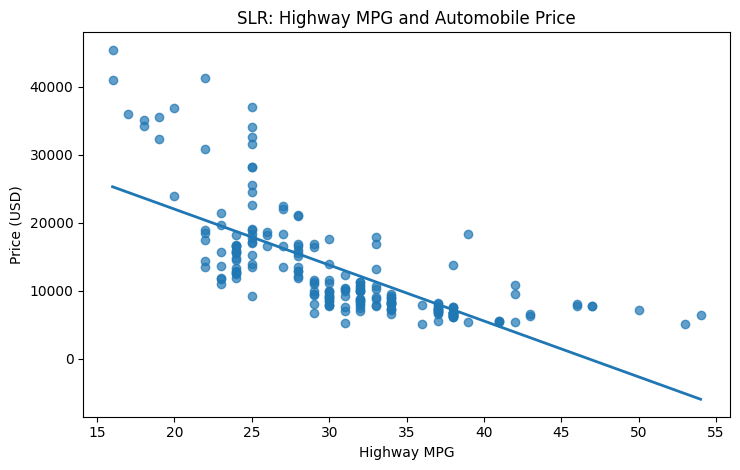

In [6]:
x = df["highway-mpg"].to_numpy()
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slr_highway.predict(pd.DataFrame({"highway-mpg": x_line}))

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(df["highway-mpg"], y, alpha=0.7)
ax.plot(x_line, y_line, linewidth=2)
ax.set_title("SLR: Highway MPG and Automobile Price")
ax.set_xlabel("Highway MPG")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.show()

## 4. SLR Model 2 — Engine Size

Notebook 03 found `engine-size` to have one of the strongest positive linear relationships with price. A second SLR model therefore evaluates how much of observed price variation can be represented by engine size alone.


In [7]:
X_engine = df[["engine-size"]]

slr_engine = LinearRegression()
slr_engine.fit(X_engine, y)

pred_engine = slr_engine.predict(X_engine)

print(f"Intercept: {slr_engine.intercept_:,.3f}")
print(f"Coefficient for engine-size: {slr_engine.coef_[0]:,.3f}")

Intercept: -7,963.339
Coefficient for engine-size: 166.860


In [8]:
engine_metrics = regression_metrics(y, pred_engine)
model_results.append({
    "Model": "SLR — Engine Size",
    **engine_metrics
})

pd.Series(engine_metrics, name="SLR — Engine Size").to_frame()

,SLR — Engine Size
R2,0.761
MSE,"15,021,126.025"
RMSE,"3,875.710"
MAE,"2,795.450"


### Interpretation

The positive coefficient indicates that larger engines are associated with higher automobile prices in the observed sample.

Because engine size was more strongly correlated with price than highway MPG in Notebook 03, this model provides a useful benchmark for assessing whether a single strong technical characteristic can explain a substantial share of price variation.


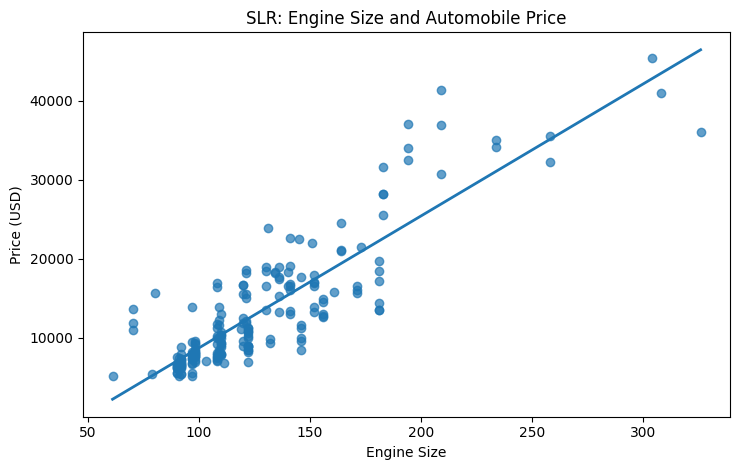

In [9]:
x = df["engine-size"].to_numpy()
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slr_engine.predict(pd.DataFrame({"engine-size": x_line}))

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(df["engine-size"], y, alpha=0.7)
ax.plot(x_line, y_line, linewidth=2)
ax.set_title("SLR: Engine Size and Automobile Price")
ax.set_xlabel("Engine Size")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.show()

## 5. Residual inspection for the SLR models

Residuals are calculated as:

**Residual = Observed Price − Predicted Price**

A useful regression specification should not leave an obvious systematic pattern in its residuals. Curvature or changing spread can indicate that a straight-line model is too restrictive or that error variability changes across the fitted range.


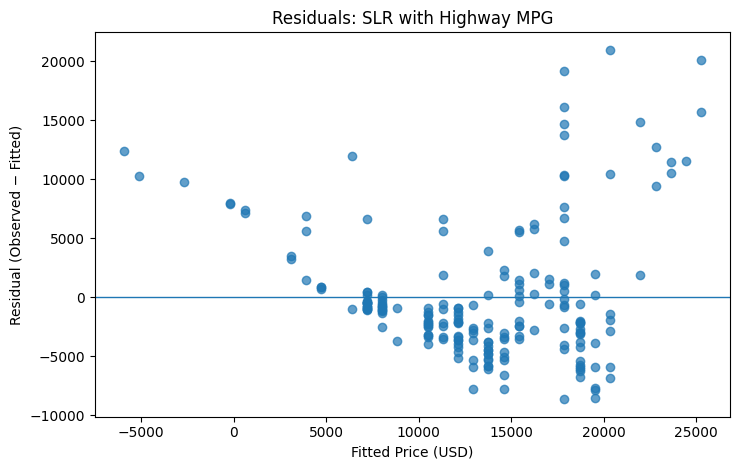

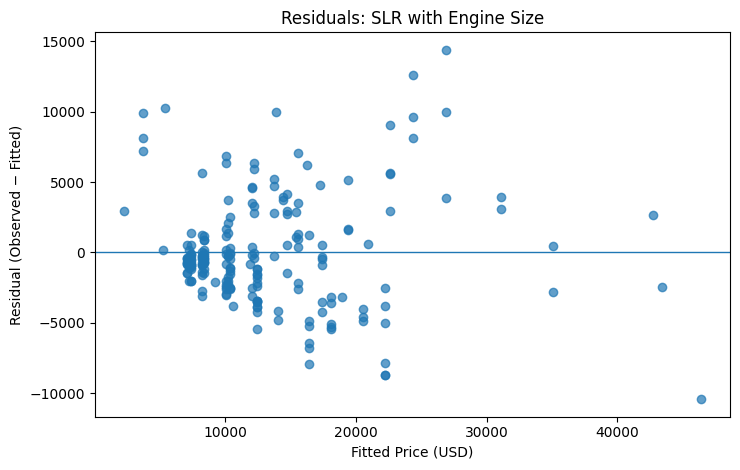

In [10]:
def residual_plot(y_true, y_pred, title):
    residuals = y_true - y_pred

    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    ax.scatter(y_pred, residuals, alpha=0.7)
    ax.axhline(0, linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Fitted Price (USD)")
    ax.set_ylabel("Residual (Observed − Fitted)")
    plt.tight_layout()
    plt.show()


residual_plot(
    y,
    pred_highway,
    "Residuals: SLR with Highway MPG"
)

residual_plot(
    y,
    pred_engine,
    "Residuals: SLR with Engine Size"
)

### Diagnostic implication

The residual plots should be interpreted alongside R² and error metrics. Visible structure in the residuals would indicate that price is not fully represented by a single straight-line relationship.

That possibility motivates two extensions:
1. combine several relevant predictors using **Multiple Linear Regression**;
2. allow a selected relationship to become nonlinear using **Polynomial Regression**.


# Part II — Multiple Linear Regression

## 6. Model specification

Notebook 03 independently confirmed that all below four variables have strong bivariate relationships with price, so we will use them as the main MLR model.

- `horsepower`
- `curb-weight`
- `engine-size`
- `highway-mpg`


However, Notebook 03 also showed that these predictors are correlated with one another. Their MLR coefficients therefore represent **conditional associations**—the relationship of each predictor with price while the other included predictors are held constant—not the same relationships measured by separate Pearson correlations.


In [11]:
mlr_features = [
    "horsepower",
    "curb-weight",
    "engine-size",
    "highway-mpg",
]

X_mlr = df[mlr_features]

mlr = LinearRegression()
mlr.fit(X_mlr, y)

pred_mlr = mlr.predict(X_mlr)

mlr_coefficients = pd.DataFrame({
    "feature": mlr_features,
    "coefficient": mlr.coef_,
})

print(f"Intercept: {mlr.intercept_:,.3f}")
mlr_coefficients

Intercept: -15,806.625


,feature,coefficient
0,horsepower,53.496
1,curb-weight,4.708
2,engine-size,81.530
3,highway-mpg,36.057


### Interpreting MLR coefficients

Each coefficient measures the estimated change in price associated with a one-unit increase in that predictor **while holding the other included predictors constant**.

Coefficient magnitude should not be used to rank variable importance directly because the predictors are measured in different units. In addition, correlated predictors can make individual coefficients less stable even when the model as a whole explains price well.


In [12]:
mlr_metrics = regression_metrics(y, pred_mlr)
model_results.append({
    "Model": "MLR — 4 Predictors",
    **mlr_metrics
})

pd.Series(mlr_metrics, name="MLR — 4 Predictors").to_frame()

,MLR — 4 Predictors
R2,0.809
MSE,"11,980,366.871"
RMSE,"3,461.267"
MAE,"2,450.801"


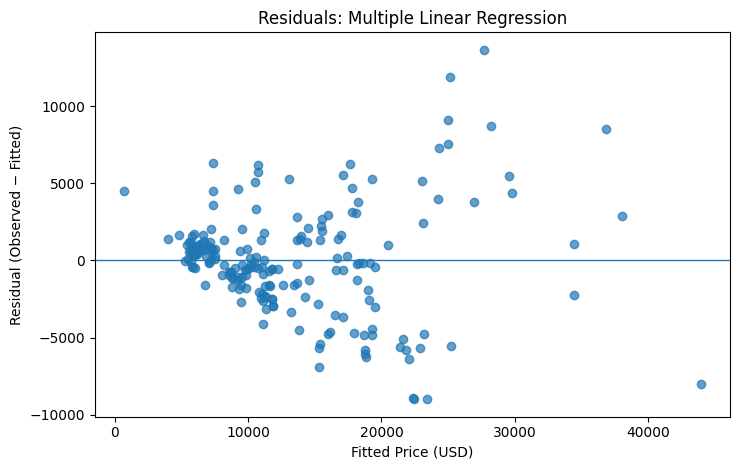

In [13]:
residual_plot(
    y,
    pred_mlr,
    "Residuals: Multiple Linear Regression"
)

## 7. Observed versus fitted price for MLR

A direct observed-versus-fitted plot shows whether predictions track the 45-degree equality line across the price range. Large departures identify observations that the specification does not reproduce well.


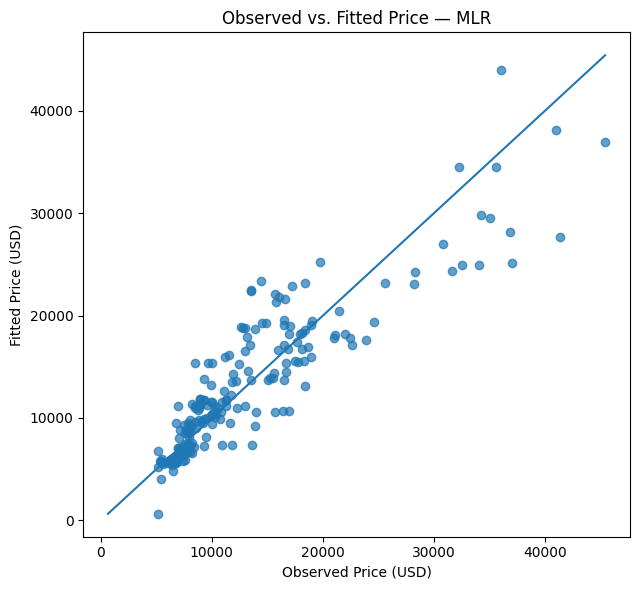

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 6.0))
ax.scatter(y, pred_mlr, alpha=0.7)

lower = min(y.min(), pred_mlr.min())
upper = max(y.max(), pred_mlr.max())

ax.plot([lower, upper], [lower, upper], linewidth=1.5)
ax.set_title("Observed vs. Fitted Price — MLR")
ax.set_xlabel("Observed Price (USD)")
ax.set_ylabel("Fitted Price (USD)")
plt.tight_layout()
plt.show()

### MLR interpretation

The MLR substantially improves fit over the SLR model of Highway MPG, while slightly improves fit over the SLR model of Engine Size. The result supports the idea that automobile price is associated with a combination of power, size/weight, engine capacity, and fuel economy rather than any single characteristic.

The remaining residual dispersion also reminds us that the model is not a complete representation of automobile pricing. Manufacturer, body configuration, drivetrain, omitted technical characteristics, and nonlinear relationships may account for additional variation.


# Part III — Polynomial Regression

## 8. Why consider a polynomial specification?

A linear regression assumes that the expected change in price is constant for each one-unit change in the predictor.

Instead, we will explore a **moderate polynomial degree** regression using `highway-mpg`. 

The purpose is not to maximize in-sample fit. It is to test whether allowing curvature captures structure that a straight line misses.


In [15]:
poly_degree = 3

poly_highway = Pipeline([
    ("polynomial_features", PolynomialFeatures(
        degree=poly_degree,
        include_bias=False
    )),
    ("linear_regression", LinearRegression()),
])

poly_highway.fit(X_highway, y)
pred_poly = poly_highway.predict(X_highway)

poly_metrics = regression_metrics(y, pred_poly)
model_results.append({
    "Model": f"Polynomial — Highway MPG (degree {poly_degree})",
    **poly_metrics
})

pd.Series(
    poly_metrics,
    name=f"Polynomial — Highway MPG (degree {poly_degree})"
).to_frame()

,Polynomial — Highway MPG (degree 3)
R2,0.674
MSE,"20,474,146.426"
RMSE,"4,524.837"
MAE,"2,951.934"


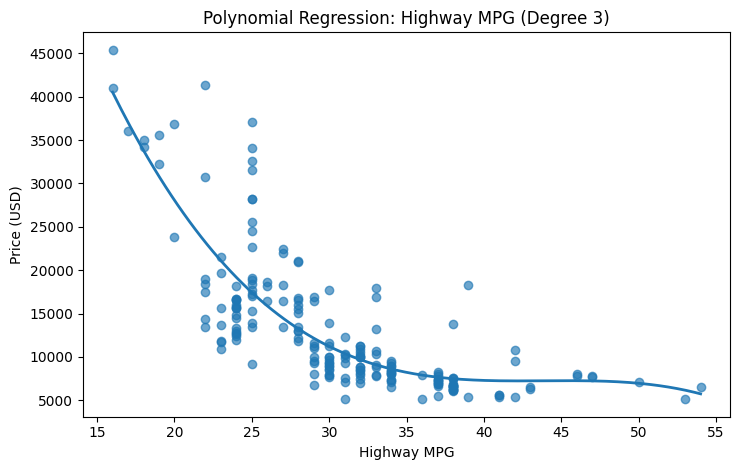

In [16]:
x_line = np.linspace(
    df["highway-mpg"].min(),
    df["highway-mpg"].max(),
    200
)

x_line_df = pd.DataFrame({"highway-mpg": x_line})
poly_line = poly_highway.predict(x_line_df)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(df["highway-mpg"], y, alpha=0.65)
ax.plot(x_line, poly_line, linewidth=2)
ax.set_title(f"Polynomial Regression: Highway MPG (Degree {poly_degree})")
ax.set_xlabel("Highway MPG")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.show()

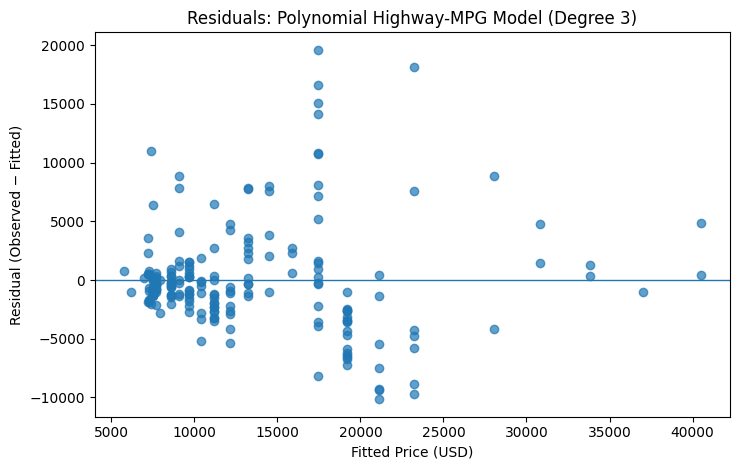

In [17]:
residual_plot(
    y,
    pred_poly,
    f"Residuals: Polynomial Highway-MPG Model (Degree {poly_degree})"
)

### Polynomial-model caution

A polynomial curve can improve in-sample fit simply because it is more flexible. That does not mean it will predict unseen automobiles better.

For this reason, Notebook 04 stops at **model development and diagnostic comparison**. The question of whether the polynomial improvement generalizes will be addressed in Notebook 05 using held-out data and cross-validation.

# Part IV — In-Sample Model Comparison

## 9. Compare model fit

The models developed above are summarized using the same metrics. Lower error values and higher R² indicate better representation of the observed estimation sample.

Again, this table does **not** identify the final model. A specification with superior in-sample fit may generalize poorly.


In [18]:
results_df = (
    pd.DataFrame(model_results)
      .set_index("Model")
      .sort_values("R2", ascending=False)
)

results_df

,R2,MSE,RMSE,MAE
Model,,,,
MLR — 4 Predictors,0.809,"11,980,366.871","3,461.267","2,450.801"
SLR — Engine Size,0.761,"15,021,126.025","3,875.710","2,795.450"
Polynomial — Highway MPG (degree 3),0.674,"20,474,146.426","4,524.837","2,951.934"
SLR — Highway MPG,0.497,"31,635,042.945","5,624.504","4,054.993"


In [19]:
display_results = results_df.copy()

display_results["R2"] = display_results["R2"].round(4)
display_results["MSE"] = display_results["MSE"].round(0)
display_results["RMSE"] = display_results["RMSE"].round(0)
display_results["MAE"] = display_results["MAE"].round(0)

display_results

,R2,MSE,RMSE,MAE
Model,,,,
MLR — 4 Predictors,0.809,"11,980,367.000","3,461.000","2,451.000"
SLR — Engine Size,0.761,"15,021,126.000","3,876.000","2,795.000"
Polynomial — Highway MPG (degree 3),0.674,"20,474,146.000","4,525.000","2,952.000"
SLR — Highway MPG,0.497,"31,635,043.000","5,625.000","4,055.000"


## 10. Model-development conclusions

This notebook establishes a transparent progression from simple to more flexible regression specifications:

### Simple Linear Regression
- `highway-mpg` provides an interpretable negative price relationship.
- `engine-size` provides a strong positive one-predictor benchmark.
- Neither one-predictor model can capture the full complexity of automobile pricing.

### Multiple Linear Regression
- Combining `horsepower`, `curb-weight`, `engine-size`, and `highway-mpg` allows several economically and technically meaningful vehicle characteristics to contribute jointly to fitted price.
- The predictors are correlated, so coefficients should be interpreted as conditional associations and with awareness of multicollinearity.

### Polynomial Regression
- A cubic highway-MPG specification allows a nonlinear relationship and can improve in-sample fit relative to a straight line.
- Greater flexibility also increases the risk of fitting sample-specific noise.

### What has *not* yet been established
The model with the best in-sample fit is **not automatically the preferred final model**. This notebook has not yet determined:

- how each model performs on unseen observations;
- whether the polynomial model is overfitting;
- how stable the results are across different samples;
- which specification offers the best balance between simplicity and generalization.

## Handoff to Notebook 05 — Regression Model Evaluation & Selection

Notebook 05 will evaluate the developed regression specifications using:

1. **train/test splitting**;
2. **cross-validation**;
3. **training-versus-testing performance comparison**;
4. **polynomial degree comparison and overfitting analysis**;
5. a final regression-model comparison and selection.
